In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import warnings
import traceback

if '../' not in sys.path:
    sys.path.append('../')

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar

plt.style.use('../input/physrev.mplstyle')
plt.rcParams['figure.dpi'] = "300"

### directory with N_eff results

In [4]:
# adm_results_dir = '../output/results/scan/'
# adm_results_dir = '/Users/duncan/scrap/admscan/adm_scan/'
# adm_results_dir = '/Users/duncan/scrap/adm_test_scans/'
adm_results_dir = '/Users/duncan/scrap/adm_scan_fine/'
# adm_results_dir = '/Users/duncan/scrap/adm_test_scans_PL/'

### Loop over directories to find all parameter points and load results

In [5]:
mde_dirs = []
mde_mdp_dirs = []

for name in os.listdir(adm_results_dir):
    if os.path.isdir(os.path.join(adm_results_dir, name)):
        mde_dirs.append(os.path.join(adm_results_dir, name))


for md in mde_dirs:
    for name in os.listdir(md):
        if os.path.isdir(os.path.join(md, name)):
            mde_mdp_dirs.append(os.path.join(md, name))
    
    

In [6]:
N_Q = 50
num_param_points = len(mde_mdp_dirs*N_Q)

m_de = np.zeros(num_param_points)
m_dp = np.zeros(num_param_points)
charges = np.zeros(num_param_points)
N_eff = np.zeros(num_param_points)
Delta_N_eff = np.zeros(num_param_points)
Delta_N_eff_dso = np.zeros(num_param_points)

R_Tnu_Tgam = np.zeros(num_param_points)
R_Tdark_Tgam = np.zeros(num_param_points)
R_Tgam_bsm_Tgam_sm = np.zeros(num_param_points)

res_ind = 0

for (i, res_dir) in enumerate(mde_mdp_dirs):
    result_files = [f for f in os.listdir(res_dir) if f.endswith('.npz')]
    
    for (j, rf) in enumerate(result_files):
        result = np.load(os.path.join(res_dir, rf))
        result_txt_fname = rf.split('.npz')[0] + '.txt'

        #very hacky way to get temperature ratios from text files
        result_txt = np.genfromtxt(
            os.path.join(res_dir, rf.split('.npz')[0] + '.txt'), 
            delimiter='=', 
            skip_footer=1,
            usecols=1
        )

        ratio_Tnu_Tg = result_txt[8]
        ratio_Td_Tg = result_txt[9]
        ratio_Tgbsm_Tgsm = result_txt[10]

        R_Tnu_Tgam[res_ind] = ratio_Tnu_Tg
        R_Tdark_Tgam[res_ind] = ratio_Td_Tg
        R_Tgam_bsm_Tgam_sm[res_ind] = ratio_Tgbsm_Tgsm 
        

        m_de[res_ind] = result['m_de']
        m_dp[res_ind] = result['m_dp']
        charges[res_ind] = result['Q']
        N_eff[res_ind] = result['N_eff_bsm']
        Delta_N_eff[res_ind] = result['Delta_Neff']
        Delta_N_eff_dso[res_ind] = result['DNeff_dso']


        res_ind += 1

failed_jobs = len(np.where(m_de == 0)[0])

In [7]:
sel = np.where(m_de > 0)

m_de = m_de[sel]
m_dp = m_dp[sel]
charges = charges[sel]
N_eff = N_eff[sel]
Delta_N_eff = Delta_N_eff[sel]
Delta_N_eff_dso = Delta_N_eff_dso[sel]

In [8]:
np.savez_compressed(
    os.path.join('../output/results/','neff_scan_result.npz'),
    m_de = m_de,
    m_dp = m_dp,
    eps = charges,
    N_eff = N_eff,
    R_Tnu_Tgam = R_Tnu_Tgam,
    R_Tdark_Tgam = R_Tdark_Tgam,
    R_Tgam_bsm_Tgam_sm = R_Tgam_bsm_Tgam_sm
    
)

### Plots

In [9]:
unique_mde = np.unique(m_de)

N_eff_results_dict = dict()
Delta_N_eff_interp_dict = dict()
Delta_N_eff_dso_interp_dict = dict()

for um_de in unique_mde:
    m_dp_um = m_dp[np.where(m_de == um_de)]

    unique_mdp = np.unique(m_dp_um)

    results_dict = dict()
    interp_dict = dict()
    interp_dict_dso = dict()

    for um_dp in unique_mdp:
        sel = np.where(
            (m_de == um_de)
           &(m_dp == um_dp)
        )

        charges_um_dp = charges[sel]
        N_eff_um_dp = N_eff[sel]
        Delta_N_eff_um_dp = Delta_N_eff[sel]
        Delta_N_eff_dso_um_dp = Delta_N_eff_dso[sel]

        sort_order = charges_um_dp.argsort()

        result_um_dp = np.array([
            charges_um_dp[sort_order], 
            N_eff_um_dp[sort_order],
            Delta_N_eff_um_dp[sort_order],
            Delta_N_eff_dso_um_dp[sort_order]
        ])

        #interpreter shouldn't have param points that failed
        Isel = np.where(N_eff_um_dp[sort_order] > 0.0)

        if np.any(N_eff_um_dp[sort_order] == 0.0):
            print('wtf')

        dne_I = interp1d(
            charges_um_dp[sort_order][Isel], 
            Delta_N_eff_um_dp[sort_order][Isel], 
            bounds_error=False, 
            fill_value=(Delta_N_eff_um_dp[sort_order][Isel][0], Delta_N_eff_um_dp[sort_order][Isel][-1])
        )

        dne_dso_I = interp1d(
            charges_um_dp[sort_order][Isel], 
            Delta_N_eff_dso_um_dp[sort_order][Isel], 
            bounds_error=False, 
            fill_value=(Delta_N_eff_dso_um_dp[sort_order][Isel][0], Delta_N_eff_dso_um_dp[sort_order][Isel][-1])
        )

        results_dict = results_dict | {um_dp: result_um_dp}
        interp_dict = interp_dict | {um_dp: dne_I}
        interp_dict_dso = interp_dict_dso | {um_dp: dne_dso_I}

    N_eff_results_dict = N_eff_results_dict | {um_de: results_dict}
    Delta_N_eff_interp_dict = Delta_N_eff_interp_dict | {um_de: interp_dict}
    Delta_N_eff_dso_interp_dict = Delta_N_eff_dso_interp_dict | {um_de: interp_dict_dso}

In [10]:
print(unique_mde)

[  0.1      0.1151   0.1326   0.1526   0.1758   0.2024   0.233    0.2683
   0.3089   0.3556   0.4095   0.4715   0.5429   0.6251   0.7197   0.8286
   0.9541   1.099    1.265    1.456    1.677    1.931    2.223    2.56
   2.947    3.393    3.907    4.498    5.179    5.964    6.866    7.906
   9.103   10.48    12.07    13.89    16.      18.42    21.21    24.42
  28.12    32.37    37.28    42.92    49.42    56.9     65.51    75.43
  86.85   100.    ]


In [11]:
eps_min = 1e-10
eps_max = 1e-4

num_eps = 50
charge_list = np.geomspace(eps_min, eps_max, num_eps)

## Make Neff contour plot in hydrogen and positronium limits

In [12]:
masses_HL = np.zeros((len(unique_mde), N_Q))
charges_HL = np.zeros((len(unique_mde), N_Q))
N_eff_HL = np.zeros((len(unique_mde), N_Q))

for (i, mass_de) in enumerate(unique_mde):

    HL_mdp_key = list(N_eff_results_dict[mass_de].keys())[-1]
    charges = N_eff_results_dict[mass_de][HL_mdp_key][0]
    N_eff = N_eff_results_dict[mass_de][HL_mdp_key][1]

    #in case of failed jobs
    num_completed = len(N_eff)

    masses_HL[i, :] = mass_de
    charges_HL[i, :] = charge_list 
    N_eff_HL[i, 0:num_completed] = N_eff

masses_PL = np.zeros((len(unique_mde), N_Q))
charges_PL = np.zeros((len(unique_mde), N_Q))
N_eff_PL = np.zeros((len(unique_mde), N_Q))

for (i, mass_de) in enumerate(unique_mde):

    PL_mdp_key = list(N_eff_results_dict[mass_de].keys())[0]
    N_eff = N_eff_results_dict[mass_de][PL_mdp_key][1]

    #in case of failed jobs
    num_completed = len(N_eff)

    masses_PL[i, :] = mass_de
    charges_PL[i, :] = charge_list 
    N_eff_PL[i, 0:num_completed] = N_eff

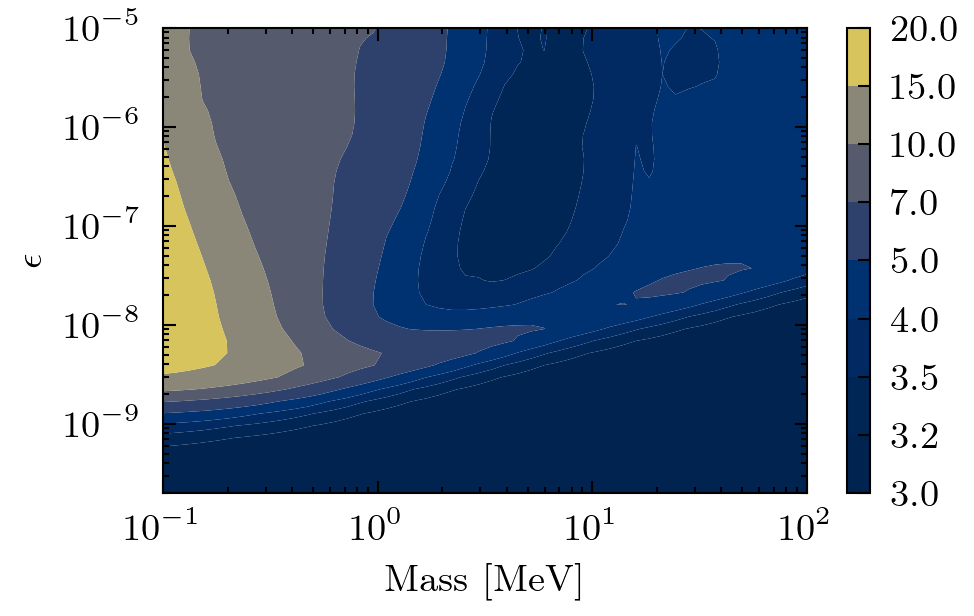

In [13]:
f, ax = plt.subplots(1, 1)
contour_levels = np.array([3.0, 3.2, 3.5, 4, 5, 7, 10, 15, 20])

plt.contourf(
    masses_HL, 
    charges_HL,
    N_eff_HL, 
    levels=contour_levels,
    antialiased=True,
    # norm='log',
    cmap='cividis'
)

plt.colorbar()

plt.xlabel('Mass [MeV]')
plt.ylabel(r'$\epsilon$')

plt.ylim(2e-10, 1e-5)

plt.xscale('log')
plt.yscale('log')

plt.savefig('../output/figures/N_eff_contour_HL.pdf')

plt.show()

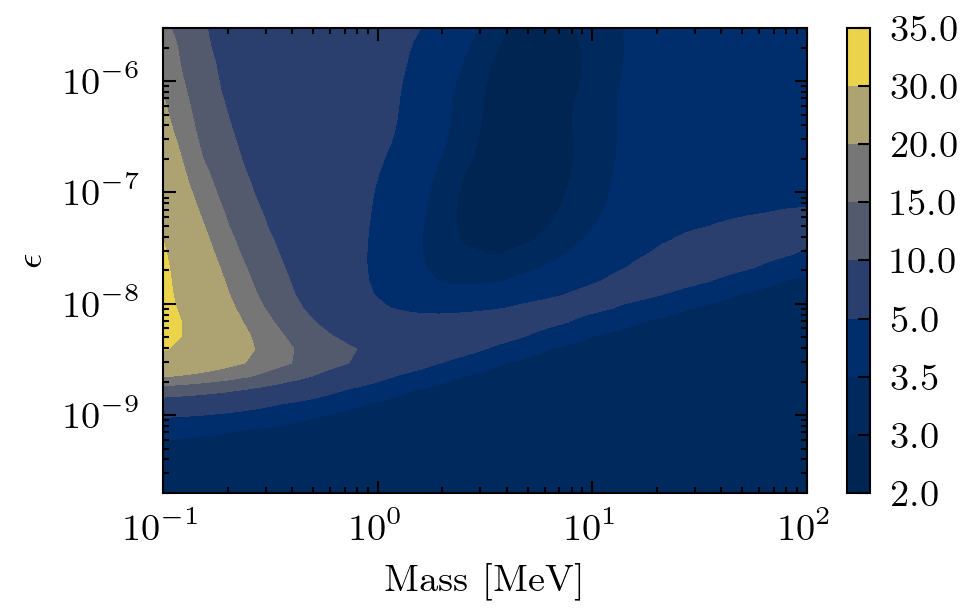

In [14]:
f, ax = plt.subplots(1, 1)

contour_levels = np.array([2.0, 3.0, 3.5, 5, 10, 15, 20, 30, 35])
# contour_levels = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5])


plt.contourf(
    masses_PL, 
    charges_PL,
    N_eff_PL, 
    levels=contour_levels,
    # antialiased=True,
    # norm='log',
    cmap='cividis'
)

plt.colorbar()

plt.xlabel('Mass [MeV]')
plt.ylabel(r'$\epsilon$')

plt.ylim(2e-10, 3e-6)
plt.xscale('log')
plt.yscale('log')

# plt.plot(masses_bad, charges_bad, linestyle='none', marker='+')
plt.savefig('../output/figures/N_eff_contour_PL.pdf')
plt.show()

## Constraint contours

In [15]:
def get_DNeff_constraint_RHS(delta_neff_Interp, constraint):
    return lambda Q: delta_neff_Interp(Q) - constraint

def find_Q_DNeff_constraint(delta_neff_Interp, constraint):
    Q_min = delta_neff_Interp.x[0]
    Q_max = delta_neff_Interp.x[-1]    
    
    try:
        constraint_res = root_scalar(
         get_DNeff_constraint_RHS(delta_neff_Interp, constraint),
         # bracket=(Q_min, Q_max),
         bracket=(Q_min, 2e-8),
         x0=2e-9
    )
        return constraint_res.root
    except Exception as e:
        print(e)
        return np.nan

In [18]:
Q_Neff_0_06_HL = np.zeros(len(Delta_N_eff_interp_dict.keys()))
Q_Neff_0_027_HL = np.zeros(len(Delta_N_eff_interp_dict.keys()))
Q_Neff_0_16_HL = np.zeros(len(Delta_N_eff_interp_dict.keys()))


Q_Neff_0_06_PL = np.zeros(len(Delta_N_eff_interp_dict.keys()))
Q_Neff_0_027_PL = np.zeros(len(Delta_N_eff_interp_dict.keys()))
Q_Neff_0_16_PL = np.zeros(len(Delta_N_eff_interp_dict.keys()))

Q_Neff_0_06_HL_DSO = np.zeros(len(Delta_N_eff_interp_dict.keys()))
Q_Neff_0_027_HL_DSO = np.zeros(len(Delta_N_eff_interp_dict.keys()))

Q_Neff_0_06_PL_DSO = np.zeros(len(Delta_N_eff_interp_dict.keys()))
Q_Neff_0_027_PL_DSO = np.zeros(len(Delta_N_eff_interp_dict.keys()))

dark_electron_masses = np.array(list(Delta_N_eff_interp_dict.keys()))


for (i, mass) in enumerate(Delta_N_eff_interp_dict.keys()):
      HL_key = list(Delta_N_eff_interp_dict[mass].keys())[-1]
      PL_key = list(Delta_N_eff_interp_dict[mass].keys())[0]
    
      Q_Neff_0_06_HL[i] = find_Q_DNeff_constraint(Delta_N_eff_interp_dict[mass][HL_key], 0.06)
      Q_Neff_0_027_HL[i] = find_Q_DNeff_constraint(Delta_N_eff_interp_dict[mass][HL_key], 0.027)
      Q_Neff_0_16_HL[i] = find_Q_DNeff_constraint(Delta_N_eff_interp_dict[mass][HL_key], 0.16)
    
      Q_Neff_0_06_PL[i] = find_Q_DNeff_constraint(Delta_N_eff_interp_dict[mass][PL_key], 0.06)
      Q_Neff_0_027_PL[i] = find_Q_DNeff_constraint(Delta_N_eff_interp_dict[mass][PL_key], 0.027)
      Q_Neff_0_16_PL[i] = find_Q_DNeff_constraint(Delta_N_eff_interp_dict[mass][PL_key], 0.16)

      Q_Neff_0_06_HL_DSO[i] = find_Q_DNeff_constraint(Delta_N_eff_dso_interp_dict[mass][HL_key], 0.06)
      Q_Neff_0_027_HL_DSO[i] = find_Q_DNeff_constraint(Delta_N_eff_dso_interp_dict[mass][HL_key], 0.027)
    
      Q_Neff_0_06_PL_DSO[i] = find_Q_DNeff_constraint(Delta_N_eff_dso_interp_dict[mass][PL_key], 0.06)
      Q_Neff_0_027_PL_DSO[i] = find_Q_DNeff_constraint(Delta_N_eff_dso_interp_dict[mass][PL_key], 0.027)

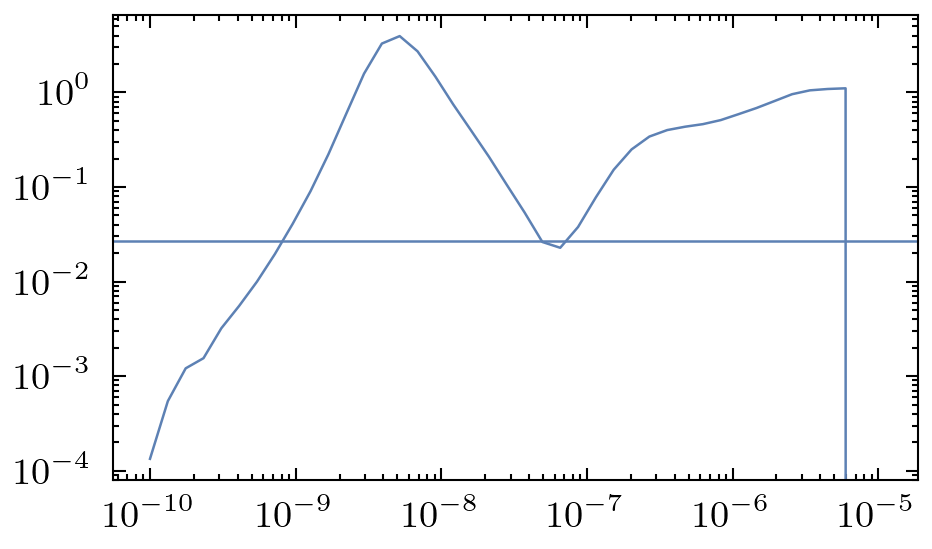

In [19]:
plt.plot(Delta_N_eff_interp_dict[2.223][2.223].x, Delta_N_eff_interp_dict[2.223][2.223].y)
plt.axhline(0.027)
plt.xscale('log')
plt.yscale('log')

In [20]:
def load_csv(file_name, skip_header=0):
    plot_data = np.genfromtxt(file_name, delimiter=',', skip_header=skip_header)
    
    x = list(zip(*plot_data))[0]
    y = list(zip(*plot_data))[1]
    
    return x, y

shelton_neff_const_0_06 = load_csv('../input/fig/2206.13530_fig1_0_06_lower_branch.csv')
shelton_neff_const_0_027 = load_csv('../input/fig/2206.13530_fig1_0_027.csv')

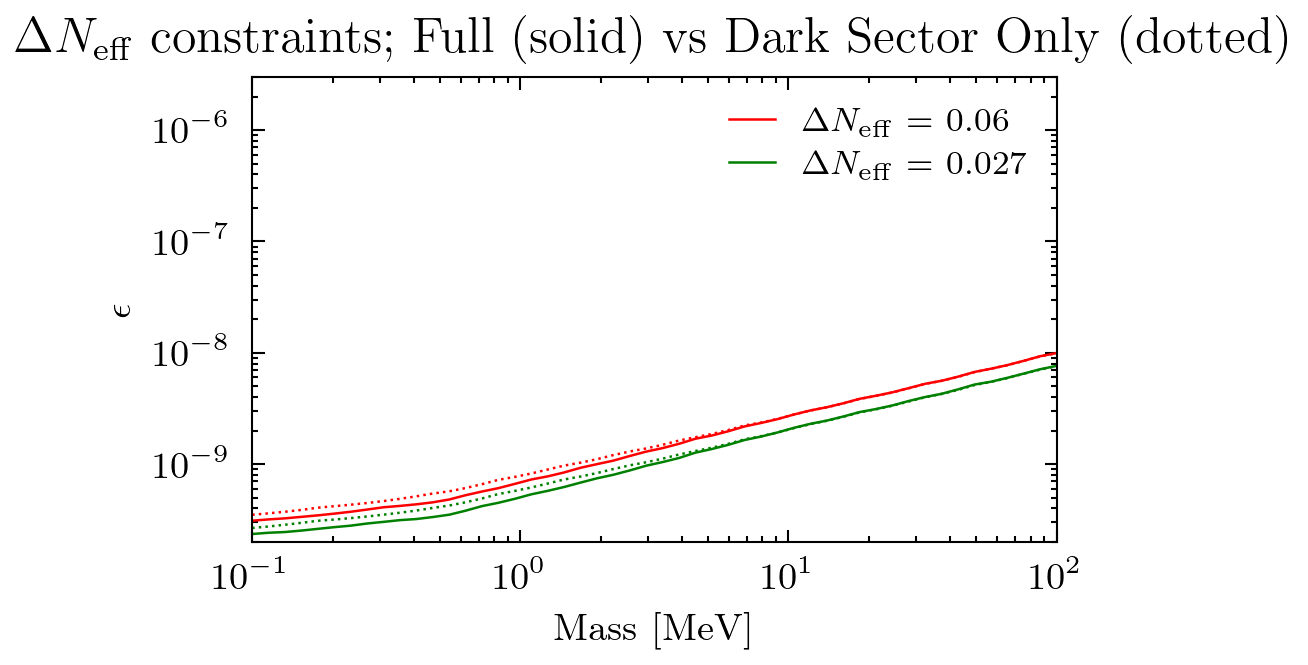

In [28]:
# plt.plot(dark_electron_masses, Q_Neff_0_06_HL, color='blue', linestyle='solid')
# plt.plot(dark_electron_masses, Q_Neff_0_027_HL, color='blue', linestyle='dashed')

plt.plot(dark_electron_masses, Q_Neff_0_06_PL, color='red', linestyle='solid', label=r'$\Delta N_{\rm eff}$ = 0.06')
plt.plot(dark_electron_masses, Q_Neff_0_027_PL, color='green', linestyle='solid', label=r'$\Delta N_{\rm eff}$ = 0.027')

plt.plot(dark_electron_masses, Q_Neff_0_06_PL_DSO, color='red', linestyle='dotted')
plt.plot(dark_electron_masses, Q_Neff_0_027_PL_DSO, color='green', linestyle='dotted')

# plt.plot(*shelton_neff_const_0_06)
# plt.plot(*shelton_neff_const_0_027)

plt.xlim(0.1, 100)
plt.ylim(2e-10, 3e-6)
plt.yscale('log')
plt.xscale('log')

plt.xlabel('Mass [MeV]')
plt.ylabel(r'$\epsilon$')

plt.legend()
plt.title(r'$\Delta N_{\rm eff}$ constraints; Full (solid) vs Dark Sector Only (dotted)')

plt.savefig('../output/figures/delta_neff_constraint_full_vs_dso.pdf')

plt.show()

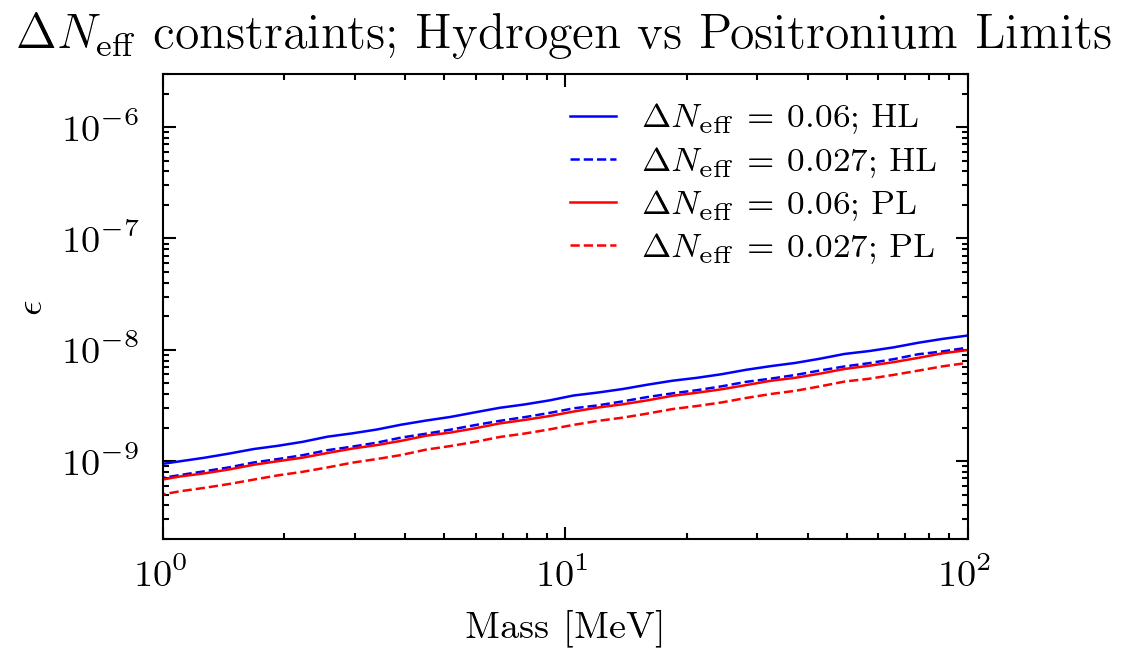

In [22]:
plt.plot(dark_electron_masses, Q_Neff_0_06_HL, color='blue', linestyle='solid', label=r'$\Delta N_{\rm eff}$ = 0.06; HL')
plt.plot(dark_electron_masses, Q_Neff_0_027_HL, color='blue', linestyle='dashed', label=r'$\Delta N_{\rm eff}$ = 0.027; HL')

plt.plot(dark_electron_masses, Q_Neff_0_06_PL, color='red', linestyle='solid', label=r'$\Delta N_{\rm eff}$ = 0.06; PL')
plt.plot(dark_electron_masses, Q_Neff_0_027_PL, color='red', linestyle='dashed', label=r'$\Delta N_{\rm eff}$ = 0.027; PL')

# plt.plot(dark_electron_masses, Q_Neff_0_06_PL_DSO, color='red', linestyle='dotted')
# plt.plot(dark_electron_masses, Q_Neff_0_027_PL_DSO, color='green', linestyle='dotted')

# plt.plot(*shelton_neff_const_0_06)
# plt.plot(*shelton_neff_const_0_027)

plt.xlim(1, 100)
plt.ylim(2e-10, 3e-6)
plt.yscale('log')
plt.xscale('log')

plt.xlabel('Mass [MeV]')
plt.ylabel(r'$\epsilon$')

plt.legend()
plt.title(r'$\Delta N_{\rm eff}$ constraints; Hydrogen vs Positronium Limits')

plt.savefig('../output/figures/delta_neff_constraint_HL_PL.pdf')

plt.show()

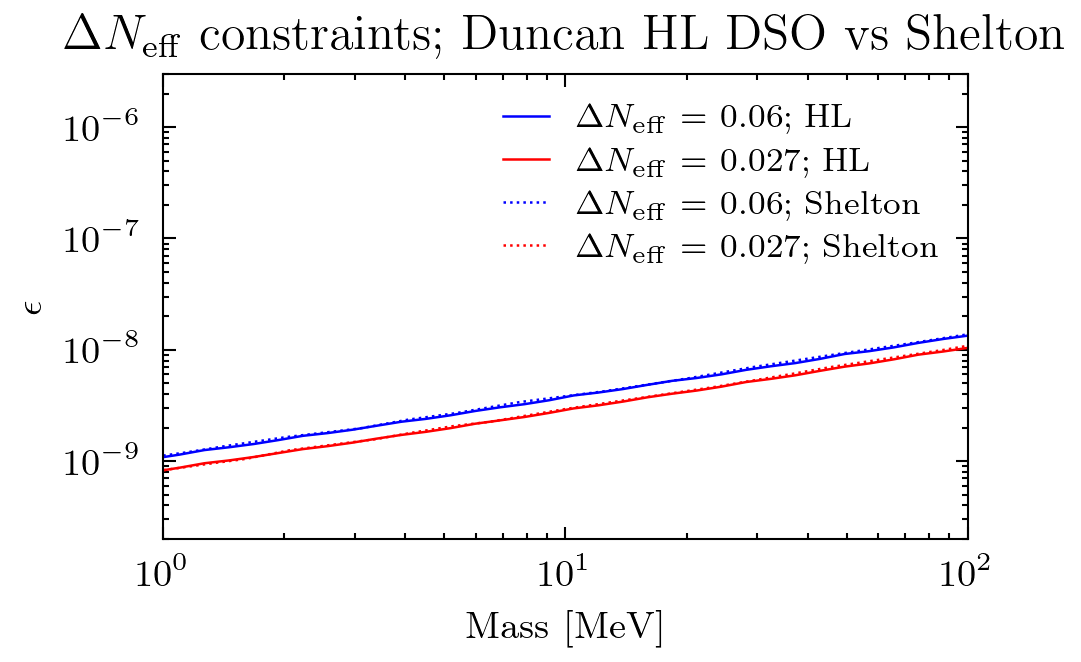

In [23]:
plt.plot(dark_electron_masses, Q_Neff_0_06_HL_DSO, color='blue', linestyle='solid', label=r'$\Delta N_{\rm eff}$ = 0.06; HL')
plt.plot(dark_electron_masses, Q_Neff_0_027_HL_DSO, color='red', linestyle='solid', label=r'$\Delta N_{\rm eff}$ = 0.027; HL')

# plt.plot(dark_electron_masses, Q_Neff_0_06_PL, color='red', linestyle='solid', label=r'$\Delta N_{\rm eff}$ = 0.06; PL')
# plt.plot(dark_electron_masses, Q_Neff_0_027_PL, color='red', linestyle='dashed', label=r'$\Delta N_{\rm eff}$ = 0.027; PL')

# plt.plot(dark_electron_masses, Q_Neff_0_06_PL_DSO, color='red', linestyle='dotted')
# plt.plot(dark_electron_masses, Q_Neff_0_027_PL_DSO, color='green', linestyle='dotted')

plt.plot(*shelton_neff_const_0_06, color='blue', linestyle='dotted', label=r'$\Delta N_{\rm eff}$ = 0.06; Shelton')
plt.plot(*shelton_neff_const_0_027, color='red', linestyle='dotted', label=r'$\Delta N_{\rm eff}$ = 0.027; Shelton')

plt.xlim(1, 100)
plt.ylim(2e-10, 3e-6)
plt.yscale('log')
plt.xscale('log')

plt.xlabel('Mass [MeV]')
plt.ylabel(r'$\epsilon$')

plt.legend()
plt.title(r'$\Delta N_{\rm eff}$ constraints; Duncan HL DSO vs Shelton')

plt.savefig('../output/figures/delta_neff_constraint_HL_shelton.pdf')

plt.show()

Text(0, 0.5, '$\\epsilon$')

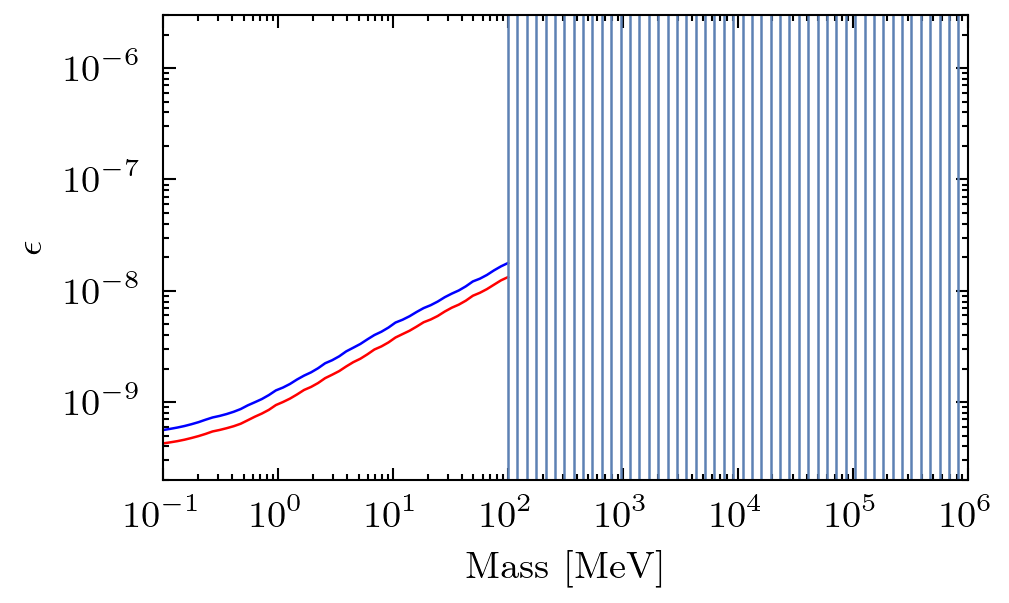

In [29]:
plt.plot(dark_electron_masses, Q_Neff_0_16_HL, color='blue', linestyle='solid', label=r'$\Delta N_{\rm eff}$ = 0.06; HL')
plt.plot(dark_electron_masses, Q_Neff_0_16_PL, color='red', linestyle='solid', label=r'$\Delta N_{\rm eff}$ = 0.027; HL')
plt.xlim(0.1, 1e6)
plt.ylim(2e-10, 3e-6)
plt.yscale('log')
plt.xscale('log')

for mtest in np.geomspace(100, 1e6):
    plt.axvline(mtest)

plt.xlabel('Mass [MeV]')
plt.ylabel(r'$\epsilon$')

### Miscellaneous stuff

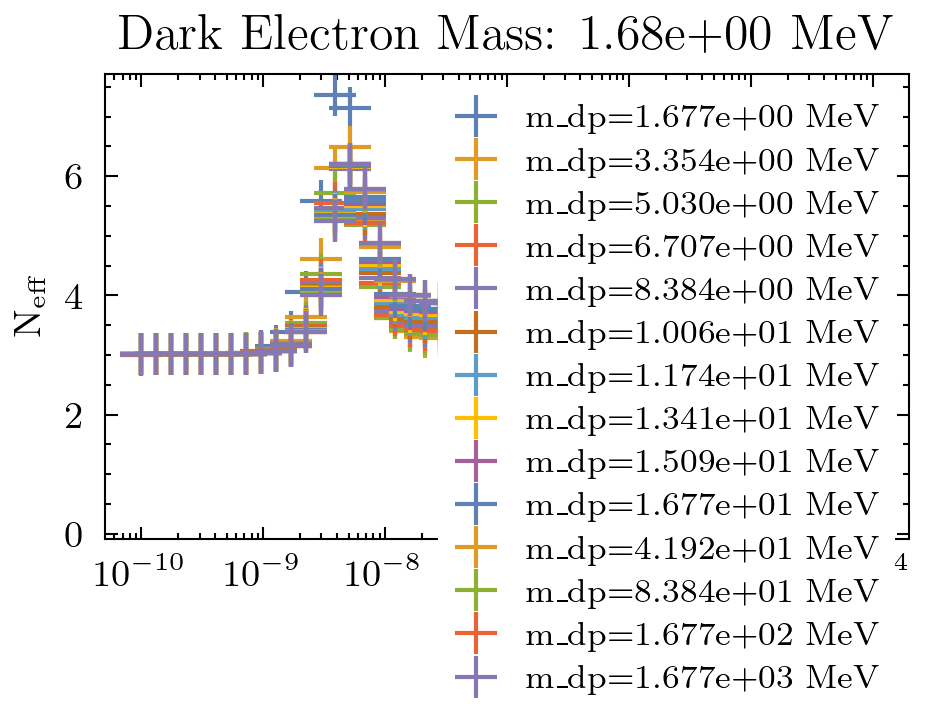

In [19]:
m_de_plot = unique_mde[20]

for m_dp in list(N_eff_results_dict[m_de_plot].keys()):
    charges_plot = N_eff_results_dict[m_de_plot][m_dp][0]
    N_eff_plot = N_eff_results_dict[m_de_plot][m_dp][1]
    
    plt.plot(charges_plot, N_eff_plot, linestyle='none', marker='+', label=f'{m_dp=:.3e} MeV')

plt.xscale('log')
plt.xlabel('Q')
plt.ylabel(r'N$_{\rm eff}$')
plt.legend()
plt.title(f'Dark Electron Mass: {m_de_plot:.2e} MeV')
plt.show()

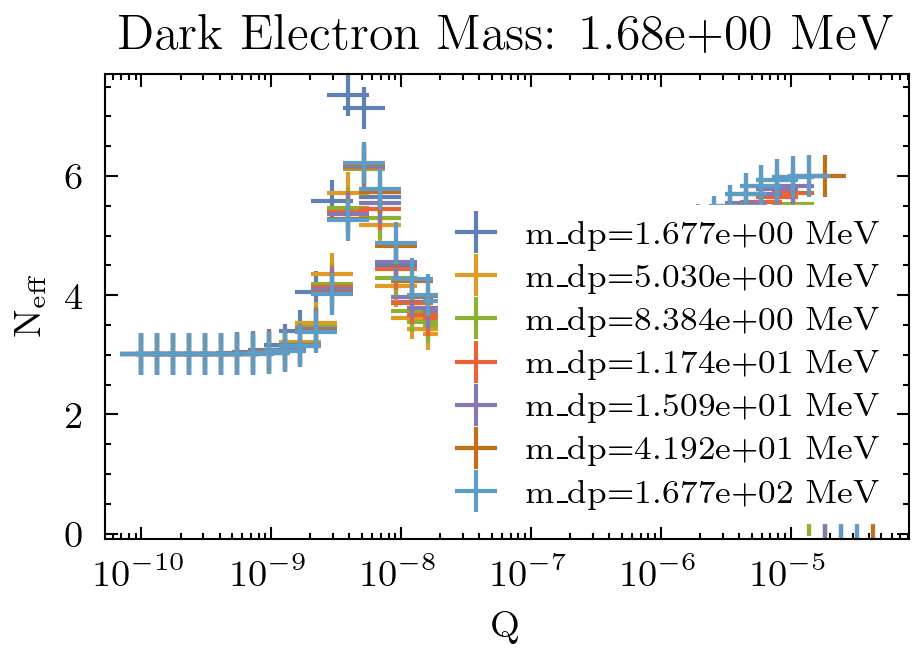

In [20]:
m_de_plot = unique_mde[20]

for m_dp in list(N_eff_results_dict[m_de_plot].keys())[::2]:
    charges_plot = N_eff_results_dict[m_de_plot][m_dp][0]
    N_eff_plot = N_eff_results_dict[m_de_plot][m_dp][1]
    
    plt.plot(charges_plot, N_eff_plot, linestyle='none', marker='+', label=f'{m_dp=:.3e} MeV')

plt.xscale('log')
plt.xlabel('Q')
plt.ylabel(r'N$_{\rm eff}$')
plt.legend(loc=4)
plt.title(f'Dark Electron Mass: {m_de_plot:.2e} MeV')
plt.show()

Text(0.5, 1.0, 'm_dp = 1000 m_de; eps = 4.095e-10')

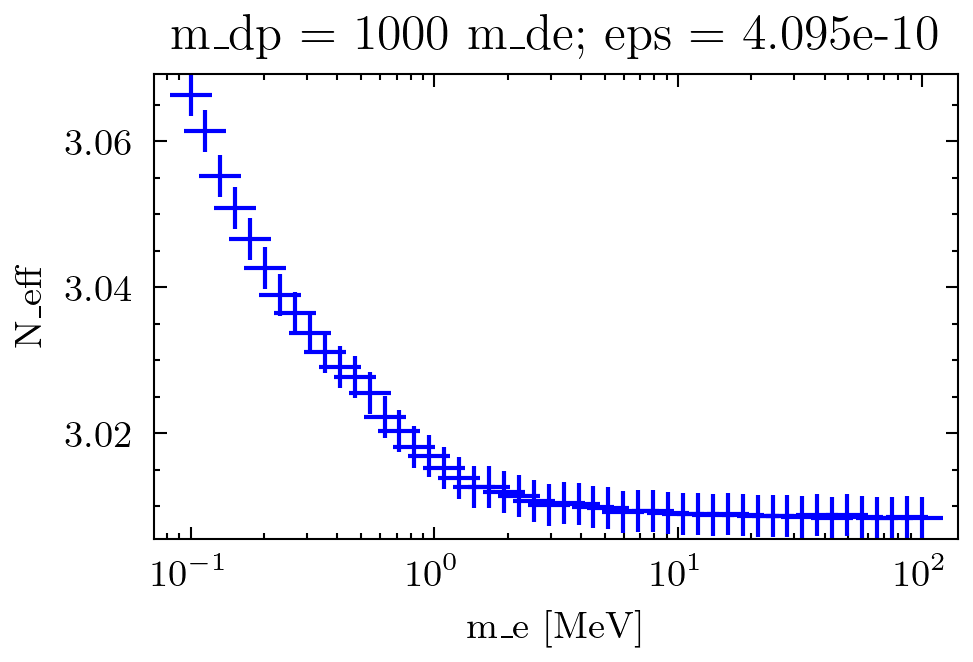

In [21]:
for m_de_plot in unique_mde:
    m_dp_plot_HL = list(N_eff_results_dict[m_de_plot].keys())[-1]
    charge = N_eff_results_dict[m_de_plot][m_dp_plot_HL][0][5]
    N_eff_BSM = N_eff_results_dict[m_de_plot][m_dp_plot_HL][1][5]
    plt.plot(m_de_plot, N_eff_BSM, marker='+', color='blue')
    plt.xscale('log')

plt.xlabel('m_e [MeV]')
plt.ylabel('N_eff')
plt.title('m_dp = 1000 m_de; eps = 4.095e-10')

In [22]:
N_eff_results_dict[0.1][100]

array([[ 1.00000000e-10,  1.32600000e-10,  1.75800000e-10,
         2.33000000e-10,  3.08900000e-10,  4.09500000e-10,
         5.42900000e-10,  7.19700000e-10,  9.54100000e-10,
         1.26500000e-09,  1.67700000e-09,  2.22300000e-09,
         2.94700000e-09,  3.90700000e-09,  5.17900000e-09,
         6.86600000e-09,  9.10300000e-09,  1.20700000e-08,
         1.60000000e-08,  2.12100000e-08,  2.81200000e-08,
         3.72800000e-08,  4.94200000e-08,  6.55100000e-08,
         8.68500000e-08,  1.15100000e-07,  1.52600000e-07,
         2.02400000e-07,  2.68300000e-07,  3.55600000e-07,
         4.71500000e-07,  6.25100000e-07,  8.28600000e-07,
         1.09900000e-06,  1.45600000e-06,  1.93100000e-06,
         2.56000000e-06,  3.39300000e-06,  4.49800000e-06,
         5.96400000e-06,  7.90600000e-06,  1.04800000e-05,
         1.38900000e-05,  1.84200000e-05,  2.44200000e-05,
         3.23700000e-05,  4.29200000e-05,  5.69000000e-05],
       [ 3.01001480e+00,  3.01143859e+00,  3.01397356e+

In [23]:
 N_eff_BSM 

3.0084496698396874

[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2.5, 5.0, 10.0, 100.0]
1e-10
[0.1151, 0.2303, 0.3454, 0.4606, 0.5757, 0.6908, 0.806, 0.9211, 1.036, 1.151, 2.878, 5.757, 11.51, 115.1]
1e-10
[0.1326, 0.2651, 0.3977, 0.5303, 0.6629, 0.7954, 0.928, 1.061, 1.193, 1.326, 3.314, 6.629, 13.26, 132.6]
1e-10
[0.1526, 0.3053, 0.4579, 0.6106, 0.7632, 0.9159, 1.068, 1.221, 1.374, 1.526, 3.816, 7.632, 15.26, 152.6]
1e-10
[0.1758, 0.3515, 0.5273, 0.703, 0.8788, 1.055, 1.23, 1.406, 1.582, 1.758, 4.394, 8.788, 17.58, 175.8]
1e-10
[0.2024, 0.4047, 0.6071, 0.8094, 1.012, 1.214, 1.417, 1.619, 1.821, 2.024, 5.059, 10.12, 20.24, 202.4]
1e-10
[0.233, 0.466, 0.699, 0.932, 1.165, 1.398, 1.631, 1.864, 2.097, 2.33, 5.825, 11.65, 23.3, 233.0]
1e-10
[0.2683, 0.5365, 0.8048, 1.073, 1.341, 1.61, 1.878, 2.146, 2.414, 2.683, 6.707, 13.41, 26.83, 268.3]
1e-10
[0.3089, 0.6178, 0.9267, 1.236, 1.544, 1.853, 2.162, 2.471, 2.78, 3.089, 7.722, 15.44, 30.89, 308.9]
1e-10
[0.3556, 0.7113, 1.067, 1.423, 1.778, 2.134, 2.49, 2

Text(0.5, 1.0, 'm_dp = 1000 m_de; eps = 4.095e-10')

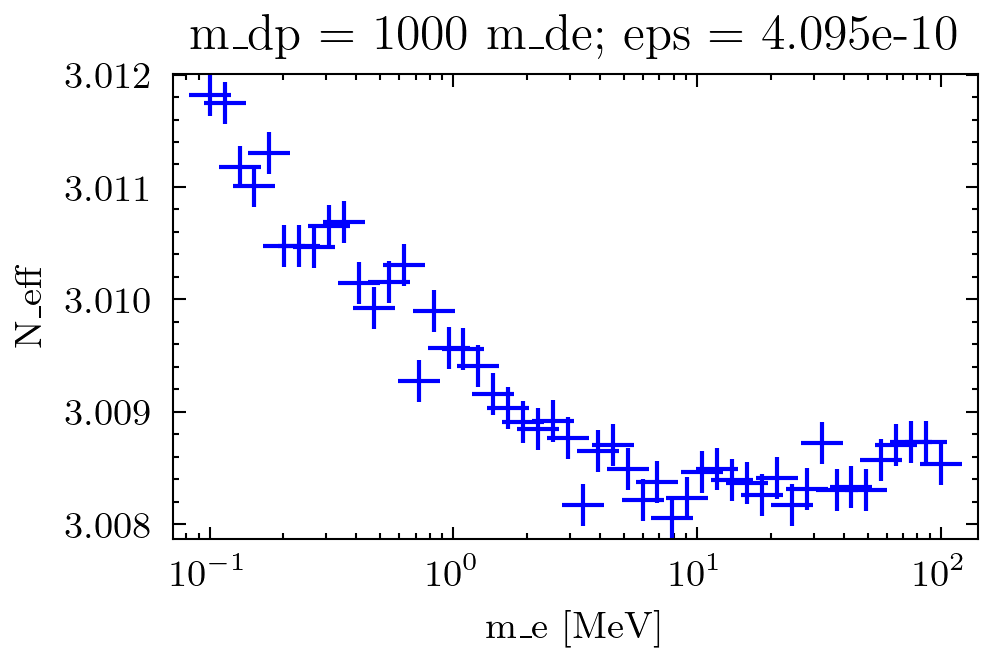

In [24]:
for m_de_plot in unique_mde:
    m_dp_plot_HL = list(N_eff_results_dict[m_de_plot].keys())[0]
    print(list(N_eff_results_dict[m_de_plot].keys()))
    charge = N_eff_results_dict[m_de_plot][m_dp_plot_HL][0][0]
    print(charge)
    N_eff_BSM = N_eff_results_dict[m_de_plot][m_dp_plot_HL][1][0]
    plt.plot(m_de_plot, N_eff_BSM, marker='+', color='blue')
    plt.xscale('log')

plt.xlabel('m_e [MeV]')
plt.ylabel('N_eff')
plt.title('m_dp = 1000 m_de; eps = 4.095e-10')